<a href="https://colab.research.google.com/github/iqbalkhanmahar271-star/Demo/blob/main/LAB02_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# -------------------- Import Libraries --------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


# -------------------- Display Settings --------------------

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid")


In [ ]:
# ============================================================
# LOAD DATASET
# ============================================================

print("=" * 70)
print("LAB 02: SIMPLE AND MULTIPLE LINEAR REGRESSION")
print("=" * 70)

# Load the Diabetes dataset
diabetes = load_diabetes()

# Create DataFrame
df = pd.DataFrame(
    diabetes.data,
    columns=diabetes.feature_names
)
# Add target column
df["target"] = diabetes.target

print("\nDataset Loaded Successfully")
print("-" * 70)
print(f"Number of samples : {df.shape[0]}")
print(f"Number of features: {len(diabetes.feature_names)}")

print("\nFirst 10 Rows:")
print("-" * 70)
print(df.head(10).to_string(index=False))


LAB 02: SIMPLE AND MULTIPLE LINEAR REGRESSION

Dataset Loaded Successfully
----------------------------------------------------------------------
Number of samples : 442
Number of features: 10

First 10 Rows:
----------------------------------------------------------------------
      age       sex       bmi        bp        s1        s2        s3        s4        s5        s6  target
 0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401 -0.002592  0.019907 -0.017646   151.0
-0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412 -0.039493 -0.068332 -0.092204    75.0
 0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356 -0.002592  0.002861 -0.025930   141.0
-0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038  0.034309  0.022688 -0.009362   206.0
 0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142 -0.002592 -0.031988 -0.046641   135.0
-0.092695 -0.044642 -0.040696 -0.019442 -0.068991 -0.079288  0.041277 -0

In [ ]:
# ============================================================
# TASK 1: EXPLORATORY DATA ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("TASK 1: EXPLORATORY DATA ANALYSIS")
print("=" * 70)

print("\nDataset Information:")
print("-" * 70)
print(df.info())

print("\nStatistical Summary:")
print("-" * 70)
print(df.describe().round(3).to_string())

print("\nMissing Values:")
print("-" * 70)
print(df.isnull().sum())


TASK 1: EXPLORATORY DATA ANALYSIS

Dataset Information:
----------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB
None

Statistical Summary:
----------------------------------------------------------------------
           age      sex      bmi       bp       s1       s2       s3       s4       s5       s6   target
count  442.000  442.000  442.000  442.000


TASK 2: CORRELATION ANALYSIS

Correlation of Features with Target:
----------------------------------------------------------------------
bmi    0.5865
s5     0.5659
bp     0.4415
s4     0.4305
s6     0.3825
s1     0.2120
age    0.1879
s2     0.1741
sex    0.0431
s3    -0.3948


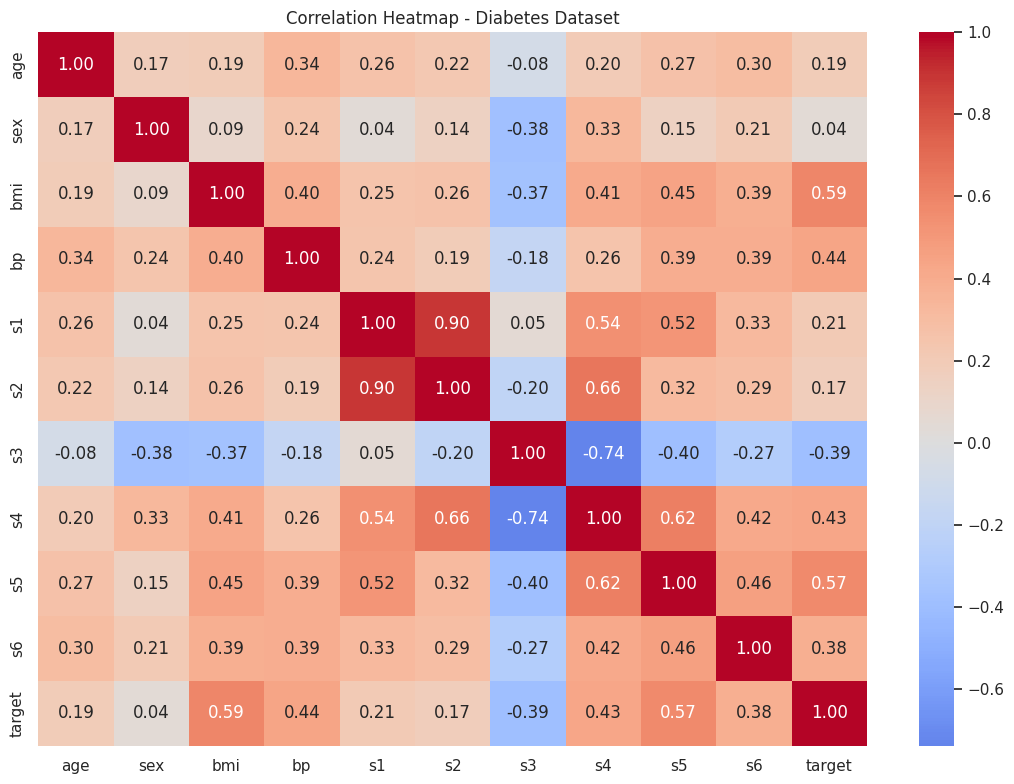

In [ ]:
# ============================================================
# TASK 2: CORRELATION ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("TASK 2: CORRELATION ANALYSIS")
print("=" * 70)

# Calculate correlation with target
correlation_with_target = (
    df.corr(numeric_only=True)["target"]
    .drop("target")
    .sort_values(ascending=False)
)

print("\nCorrelation of Features with Target:")
print("-" * 70)
print(correlation_with_target.round(4).to_string())

# Correlation heatmap
plt.figure(figsize=(11, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap - Diabetes Dataset")
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# TASK 3: SIMPLE LINEAR REGRESSION
# ============================================================

print("\n" + "=" * 70)
print("TASK 3: SIMPLE LINEAR REGRESSION")
print("=" * 70)

# Select BMI as the only feature
X_simple = df[["bmi"]]
y = df["target"]

# Split data into training and testing sets
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple,
    y,
    test_size=0.20,
    random_state=42
)

# Create Linear Regression model
simple_model = LinearRegression()

# Train the model
simple_model.fit(X_train_s, y_train_s)

# Make predictions
y_pred_s = simple_model.predict(X_test_s)

# Calculate evaluation metrics
mse_simple = mean_squared_error(y_test_s, y_pred_s)
rmse_simple = np.sqrt(mse_simple)
r2_simple = r2_score(y_test_s, y_pred_s)

print("\nSimple Linear Regression using BMI")
print("-" * 70)

print(f"Coefficient (Slope): {simple_model.coef_[0]:.4f}")
print(f"Intercept          : {simple_model.intercept_:.4f}")
print(f"MSE                : {mse_simple:.4f}")
print(f"RMSE               : {rmse_simple:.4f}")
print(f"R² Score           : {r2_simple:.4f}")


TASK 3: SIMPLE LINEAR REGRESSION

Simple Linear Regression using BMI
----------------------------------------------------------------------
Coefficient (Slope): 998.5777
Intercept          : 152.0034
MSE                : 4061.8259
RMSE               : 63.7325
R² Score           : 0.2334


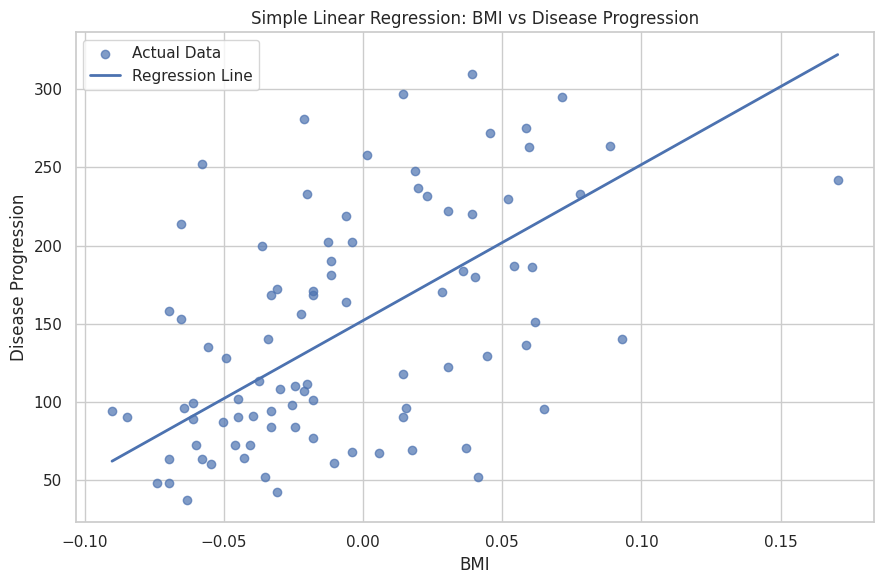

In [ ]:
# ============================================================
# BMI VS TARGET - SCATTER PLOT
# ============================================================

plt.figure(figsize=(9, 6))

plt.scatter(
    X_test_s["bmi"],
    y_test_s,
    alpha=0.7,
    label="Actual Data"
)

# Sort values for a clean regression line
sorted_indices = np.argsort(X_test_s["bmi"].values)

plt.plot(
    X_test_s["bmi"].values[sorted_indices],
    y_pred_s[sorted_indices],
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.title("Simple Linear Regression: BMI vs Disease Progression")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# TASK 4: MULTIPLE LINEAR REGRESSION
# ============================================================
print("\n" + "=" * 70)
print("TASK 4: MULTIPLE LINEAR REGRESSION")
print("=" * 70)

# Use all 10 features
feature_names = diabetes.feature_names

X_multiple = df[feature_names]
y = df["target"]

# Split data
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multiple,
    y,
    test_size=0.20,
    random_state=42
)
# Create Multiple Linear Regression model
multiple_model = LinearRegression()
# Train the model
multiple_model.fit(X_train_m, y_train_m)
# Make predictions
y_pred_m = multiple_model.predict(X_test_m)

# Calculate metrics
mse_multiple = mean_squared_error(y_test_m, y_pred_m)
rmse_multiple = np.sqrt(mse_multiple)
r2_multiple = r2_score(y_test_m, y_pred_m)

print("\nMultiple Linear Regression using All 10 Features")
print("-" * 70)

print(f"MSE      : {mse_multiple:.4f}")
print(f"RMSE     : {rmse_multiple:.4f}")
print(f"R² Score : {r2_multiple:.4f}")


TASK 4: MULTIPLE LINEAR REGRESSION

Multiple Linear Regression using All 10 Features
----------------------------------------------------------------------
MSE      : 2900.1936
RMSE     : 53.8534
R² Score : 0.4526



TASK 5: ACTUAL VS PREDICTED VALUES

First 10 Predictions:
----------------------------------------------------------------------
 Actual  Predicted
  219.0     139.55
   70.0     179.52
  202.0     134.04
  230.0     291.42
  111.0     123.79
   84.0      92.17
  242.0     258.23
  272.0     181.34
   94.0      90.22
   96.0     108.63


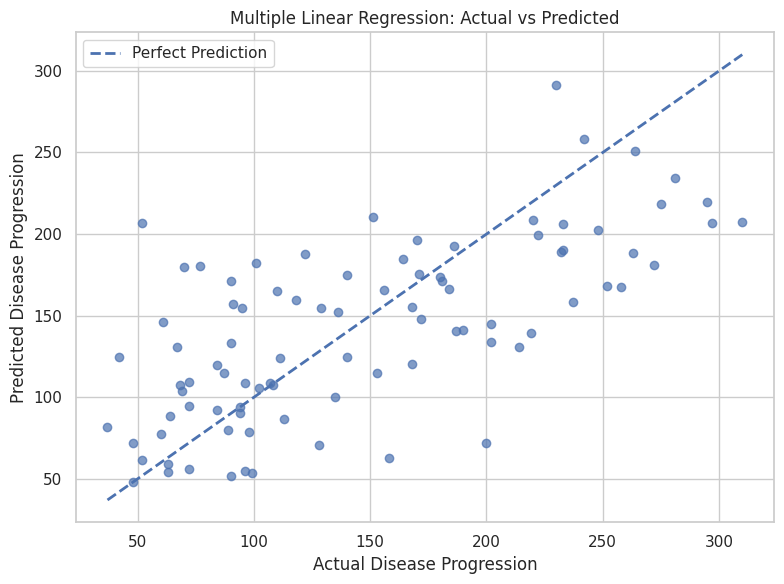

In [ ]:
# ============================================================
# TASK 5: ACTUAL VS PREDICTED
# ============================================================

print("\n" + "=" * 70)
print("TASK 5: ACTUAL VS PREDICTED VALUES")
print("=" * 70)

results = pd.DataFrame({
    "Actual": y_test_m.values,
    "Predicted": y_pred_m
})

print("\nFirst 10 Predictions:")
print("-" * 70)
print(results.head(10).round(2).to_string(index=False))


# Actual vs Predicted plot
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_m,
    y_pred_m,
    alpha=0.7
)

# Perfect prediction reference line
minimum = min(y_test_m.min(), y_pred_m.min())
maximum = max(y_test_m.max(), y_pred_m.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Disease Progression")
plt.ylabel("Predicted Disease Progression")
plt.title("Multiple Linear Regression: Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()



TASK 6: RESIDUAL ANALYSIS

Residual Statistics:
----------------------------------------------------------------------
Mean Residual: 3.9128
Std Residual : 54.0154


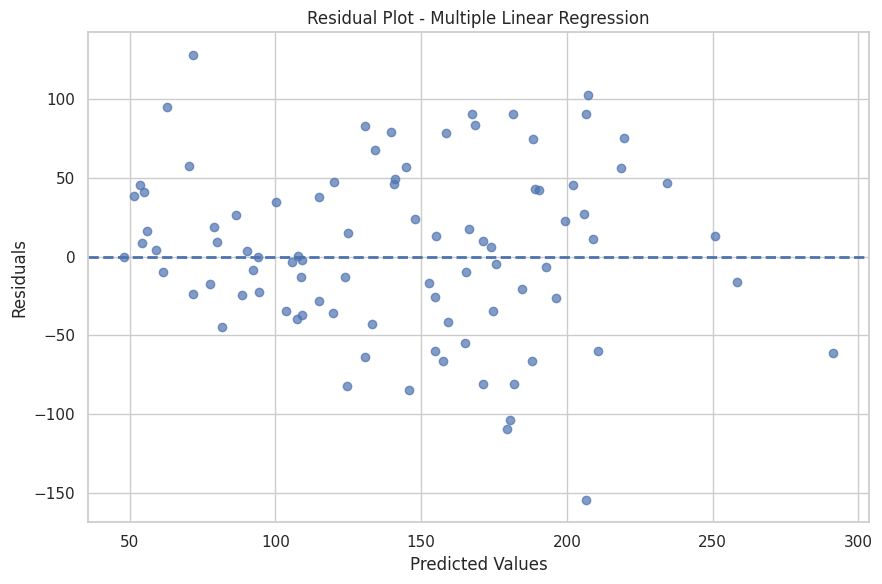

In [ ]:
# ============================================================
# TASK 6: RESIDUAL PLOT
# ============================================================

print("\n" + "=" * 70)
print("TASK 6: RESIDUAL ANALYSIS")
print("=" * 70)

# Calculate residuals
residuals = y_test_m - y_pred_m

print("\nResidual Statistics:")
print("-" * 70)
print(f"Mean Residual: {residuals.mean():.4f}")
print(f"Std Residual : {residuals.std():.4f}")

plt.figure(figsize=(9, 6))

plt.scatter(
    y_pred_m,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - Multiple Linear Regression")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# TASK 7: FEATURE CONTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("TASK 7: FEATURE CONTRIBUTION")
print("=" * 70)

# Standardize features so coefficient magnitudes
# can be compared more fairly
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_multiple)

X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = (
    train_test_split(
        X_scaled,
        y,
        test_size=0.20,
        random_state=42
    )
)

# Train regression model using standardized features
standardized_model = LinearRegression()
standardized_model.fit(X_train_scaled, y_train_scaled)

# Create coefficient table
coefficient_table = pd.DataFrame({
    "Feature": feature_names,
    "Standardized Coefficient": standardized_model.coef_
})

coefficient_table["Absolute Contribution"] = (
    coefficient_table["Standardized Coefficient"].abs()
)

coefficient_table = coefficient_table.sort_values(
    by="Absolute Contribution",
    ascending=False
)

print("\nFeature Contribution Ranking:")
print("-" * 70)
print(coefficient_table.round(4).to_string(index=False))

most_contributing_feature = coefficient_table.iloc[0]["Feature"]

print(
    f"\nFeature with the largest standardized coefficient magnitude: "
    f"{most_contributing_feature}"
)



TASK 7: FEATURE CONTRIBUTION

Feature Contribution Ranking:
----------------------------------------------------------------------
Feature  Standardized Coefficient  Absolute Contribution
     s1                  -44.3064                44.3064
     s5                   35.0174                35.0174
    bmi                   25.8007                25.8007
     s2                   24.6417                24.6417
     bp                   16.5386                16.5386
     s4                   13.0955                13.0955
    sex                  -11.5091                11.5091
     s3                    7.7731                 7.7731
     s6                    2.3150                 2.3150
    age                    1.8029                 1.8029

Feature with the largest standardized coefficient magnitude: s1


In [ ]:
# ============================================================
# TASK 8: SIMPLE VS MULTIPLE REGRESSION COMPARISON
# ============================================================

print("\n" + "=" * 70)
print("TASK 8: MODEL COMPARISON")
print("=" * 70)

comparison = pd.DataFrame({
    "Model": [
        "Simple Linear Regression (BMI)",
        "Multiple Linear Regression (10 Features)"
    ],
    "MSE": [
        mse_simple,
        mse_multiple
    ],
    "RMSE": [
        rmse_simple,
        rmse_multiple
    ],
    "R² Score": [
        r2_simple,
        r2_multiple
    ]
})

print("\nPerformance Comparison:")
print("-" * 70)
print(comparison.round(4).to_string(index=False))


TASK 8: MODEL COMPARISON

Performance Comparison:
----------------------------------------------------------------------
                                   Model       MSE    RMSE  R² Score
          Simple Linear Regression (BMI) 4061.8259 63.7325    0.2334
Multiple Linear Regression (10 Features) 2900.1936 53.8534    0.4526


In [ ]:

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("LAB 02 COMPLETED SUCCESSFULLY")
print("=" * 70)

print(f"\nSimple Regression R²      : {r2_simple:.4f}")
print(f"Multiple Regression R²    : {r2_multiple:.4f}")
print(f"Simple Regression RMSE    : {rmse_simple:.4f}")
print(f"Multiple Regression RMSE  : {rmse_multiple:.4f}")

print("\nAll required Lab 02 tasks have been completed.")
print("=" * 70)


LAB 02 COMPLETED SUCCESSFULLY

Simple Regression R²      : 0.2334
Multiple Regression R²    : 0.4526
Simple Regression RMSE    : 63.7325
Multiple Regression RMSE  : 53.8534

All required Lab 02 tasks have been completed.


Dataset loaded successfully
Dataset shape: (569, 30)

First 5 rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimensio

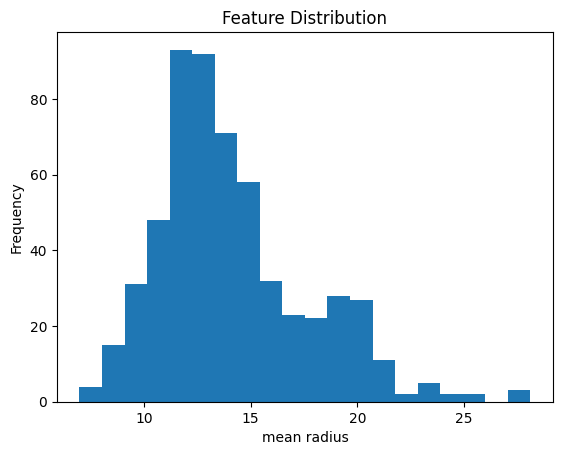


Accuracy: 0.9415204678362573

Confusion Matrix:
[[ 60   3]
 [  7 101]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92        63
           1       0.97      0.94      0.95       108

    accuracy                           0.94       171
   macro avg       0.93      0.94      0.94       171
weighted avg       0.94      0.94      0.94       171



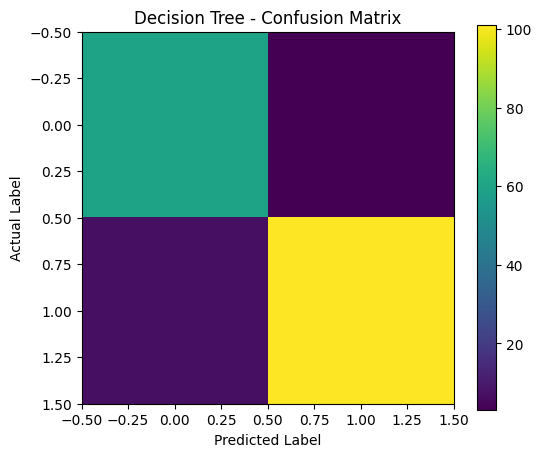

In [ ]:
# LAB 04 - DECISION TREE CLASSIFIER

# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


# Step 2: Load Dataset
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset loaded successfully")
print("Dataset shape:", X.shape)


# Step 3: Display First Few Rows
df = pd.DataFrame(X, columns=data.feature_names)

print("\nFirst 5 rows:")
print(df.head())


# Step 4: Check Missing Values
print("\nMissing values:")
print(df.isnull().sum())


# Step 5: Check Class Distribution
print("\nClass Distribution:")
print(pd.Series(y).value_counts())

print("\nClass Names:")
print(data.target_names)


# Step 6: Visualize Feature Distribution
plt.hist(X[:, 0], bins=20)

plt.xlabel(data.feature_names[0])
plt.ylabel("Frequency")
plt.title("Feature Distribution")

plt.show()


# Step 7: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)


# Step 8: Create Decision Tree Model
model = DecisionTreeClassifier(random_state=42)


# Step 9: Train Model
model.fit(X_train, y_train)


# Step 10: Make Predictions
y_pred = model.predict(X_test)


# Step 11: Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)


# Step 12: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


# Step 13: Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# Step 14: Visualize Confusion Matrix
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.colorbar()

plt.show()